### Libraries ###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

### Load Data ###

In [5]:
price = pd.read_csv("../data/price.csv", index_col="Date", parse_dates=True)

In [6]:
ticker         = ["AAPL", "MSFT", "JPM", "SPY"]
weight         = np.array([0.3, 0.3, 0.2, 0.2])
portfolio_v    = 100_000

daily_r     = price.pct_change().dropna()
portfolio_r = daily_r.dot(weight)

### VaR Across Confidence Levels ###

In [7]:
confi_level = [0.90, 0.95, 0.99]

mu    = portfolio_r.mean()
sigma = portfolio_r.std()

results = []

for cl in confi_level:
    # historical
    hist_var  = np.percentile(portfolio_r, (1 - cl) * 100)
    hist_cvar = portfolio_r[portfolio_r <= hist_var].mean()

    # parametric
    z         = norm.ppf(1 - cl)
    param_var  = mu + z * sigma
    param_cvar = mu - sigma * norm.pdf(z) / (1 - cl)

    results.append({
        "Confidence"  : f"{int(cl*100)}%",
        "Hist VaR"    : hist_var,
        "Hist CVaR"   : hist_cvar,
        "Param VaR"   : param_var,
        "Param CVaR"  : param_cvar,
        "Dollar Hist" : portfolio_v * abs(hist_var),
        "Dollar Param": portfolio_v * abs(param_var),
    })

df_cl = pd.DataFrame(results)

print("=" * 65)
print("        VaR ACROSS CONFIDENCE LEVELS")
print("=" * 65)
print(f"  {'Level':<8} {'Hist VaR':>10} {'Param VaR':>10} {'Hist CVaR':>10} {'Param CVaR':>10}")
print("-" * 65)
for _, row in df_cl.iterrows():
    print(f"  {row['Confidence']:<8} {row['Hist VaR']*100:>9.2f}% "
          f"{row['Param VaR']*100:>9.2f}% "
          f"{row['Hist CVaR']*100:>9.2f}% "
          f"{row['Param CVaR']*100:>9.2f}%")
print("=" * 65)

        VaR ACROSS CONFIDENCE LEVELS
  Level      Hist VaR  Param VaR  Hist CVaR Param CVaR
-----------------------------------------------------------------
  90%          -1.64%     -2.08%     -2.93%     -2.88%
  95%          -2.38%     -2.70%     -3.88%     -3.40%
  99%          -4.42%     -3.85%     -6.66%     -4.42%


### Visualize Confidence Levels ###

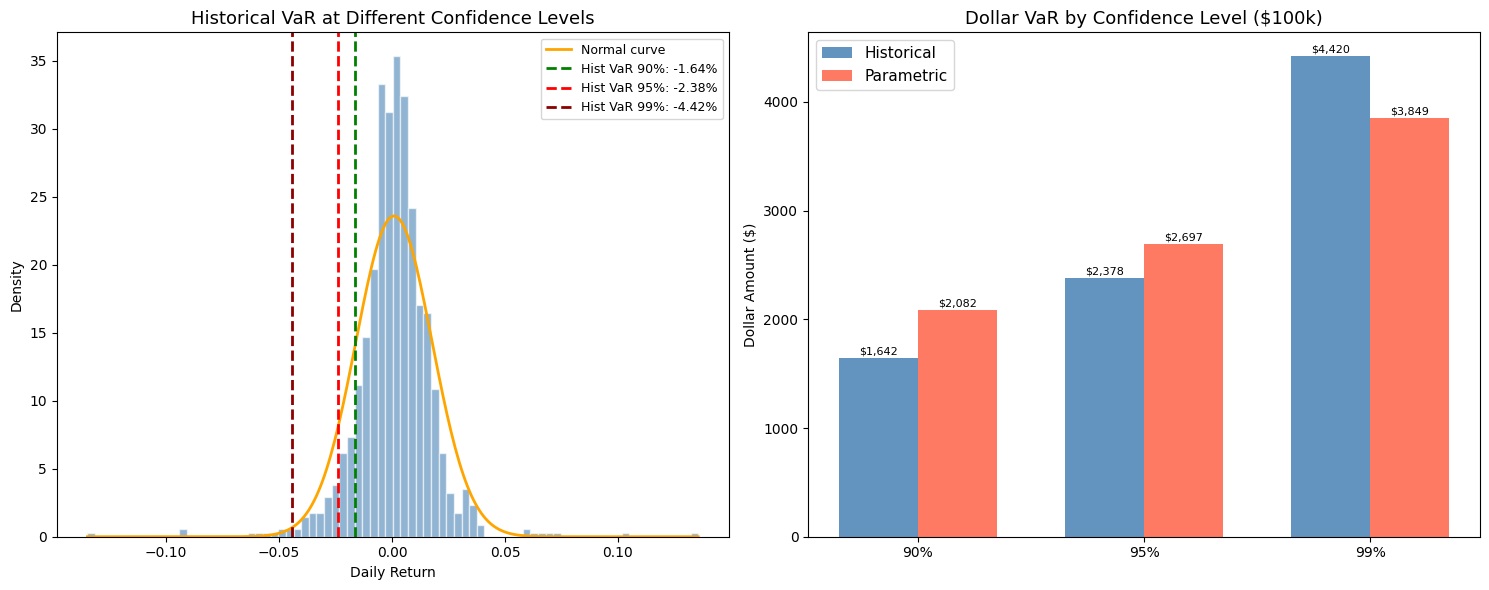

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.linspace(portfolio_r.min(), portfolio_r.max(), 300)
axes[0].hist(portfolio_r, bins=80, density=True,
              color="steelblue", edgecolor="white", alpha=0.6)
axes[0].plot(x, norm.pdf(x, mu, sigma), color="orange", 
              linewidth=2, label="Normal curve")

colors = ["green", "red", "darkred"]
for i, row in df_cl.iterrows():
    axes[0].axvline(row["Hist VaR"], color=colors[i], linewidth=2,
                     linestyle="--", label=f"Hist VaR {row['Confidence']}: {row['Hist VaR']*100:.2f}%")

axes[0].set_title("Historical VaR at Different Confidence Levels", fontsize=13)
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

x_pos  = np.arange(len(confi_level))
width  = 0.35
bars1  = axes[1].bar(x_pos - width/2, df_cl["Dollar Hist"],  width,
                      label="Historical", color="steelblue", alpha=0.85)
bars2  = axes[1].bar(x_pos + width/2, df_cl["Dollar Param"], width,
                      label="Parametric", color="tomato",    alpha=0.85)

for bar in bars1 + bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 15,
                  f"${bar.get_height():,.0f}",
                  ha="center", va="bottom", fontsize=8)

axes[1].set_title("Dollar VaR by Confidence Level ($100k)", fontsize=13)
axes[1].set_ylabel("Dollar Amount ($)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(["90%", "95%", "99%"])
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("../data/adv1_confidence_levels.png", dpi=150)
plt.show()

### Defining Weight Scenarios ###

In [9]:
scen = {
    "Current       ": np.array([0.30, 0.30, 0.20, 0.20]),
    "Equal Weights ": np.array([0.25, 0.25, 0.25, 0.25]),
    "Tech Heavy    ": np.array([0.45, 0.45, 0.05, 0.05]),
    "Finance Heavy ": np.array([0.15, 0.15, 0.60, 0.10]),
    "SPY Heavy     ": np.array([0.15, 0.15, 0.10, 0.60]),
    "AAPL Only     ": np.array([1.00, 0.00, 0.00, 0.00]),
}

for name, w in scen.items():
    assert abs(w.sum() - 1.0) < 1e-9, f"{name} weights don't sum to 1!"

for name, w in scen.items():
    print(f"  {name} → AAPL:{w[0]:.0%}  MSFT:{w[1]:.0%}  JPM:{w[2]:.0%}  SPY:{w[3]:.0%}")

  Current        → AAPL:30%  MSFT:30%  JPM:20%  SPY:20%
  Equal Weights  → AAPL:25%  MSFT:25%  JPM:25%  SPY:25%
  Tech Heavy     → AAPL:45%  MSFT:45%  JPM:5%  SPY:5%
  Finance Heavy  → AAPL:15%  MSFT:15%  JPM:60%  SPY:10%
  SPY Heavy      → AAPL:15%  MSFT:15%  JPM:10%  SPY:60%
  AAPL Only      → AAPL:100%  MSFT:0%  JPM:0%  SPY:0%


### Calculate VaR for Each Scenario ###

In [10]:
cl = 0.95
sens_results = []

for name, w in scen.items():
    r         = daily_r.dot(w)
    hist_var  = np.percentile(r, (1 - cl) * 100)
    hist_cvar = r[r <= hist_var].mean()
    m, s      = r.mean(), r.std()
    z         = norm.ppf(1 - cl)
    param_var  = m + z * s

    sens_results.append({
        "Scenario"   : name.strip(),
        "Mean Ret"   : m,
        "Volatility" : s,
        "Hist VaR"   : hist_var,
        "Hist CVaR"  : hist_cvar,
        "Param VaR"  : param_var,
        "Dollar VaR" : portfolio_v * abs(hist_var),
    })

df_sens = pd.DataFrame(sens_results)

print("=" * 70)
print("           SENSITIVITY ANALYSIS — VaR BY WEIGHT SCENARIO")
print("=" * 70)
print(f"  {'Scenario':<18} {'Volatility':>10} {'Hist VaR':>10} {'Param VaR':>10} {'$ VaR':>10}")
print("-" * 70)
for _, row in df_sens.iterrows():
    print(f"  {row['Scenario']:<18} {row['Volatility']*100:>9.3f}% "
          f"{row['Hist VaR']*100:>9.2f}% "
          f"{row['Param VaR']*100:>9.2f}% "
          f"${row['Dollar VaR']:>8,.0f}")
print("=" * 70)

           SENSITIVITY ANALYSIS — VaR BY WEIGHT SCENARIO
  Scenario           Volatility   Hist VaR  Param VaR      $ VaR
----------------------------------------------------------------------
  Current                1.691%     -2.38%     -2.70% $   2,378
  Equal Weights          1.671%     -2.36%     -2.66% $   2,358
  Tech Heavy             1.786%     -2.43%     -2.85% $   2,425
  Finance Heavy          1.800%     -2.54%     -2.86% $   2,544
  SPY Heavy              1.542%     -2.17%     -2.47% $   2,171
  AAPL Only              2.115%     -3.24%     -3.36% $   3,241


### Visualize Sensitivity ###

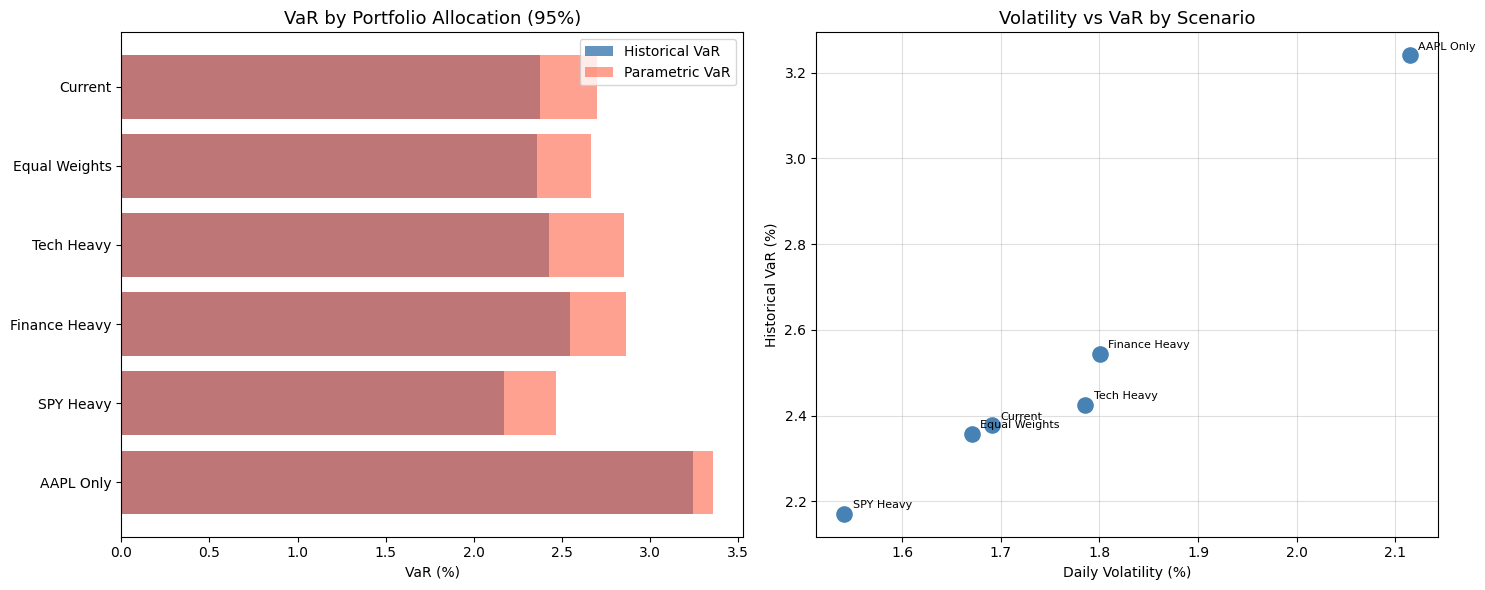

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scen_names = df_sens["Scenario"]
x_pos          = np.arange(len(scen_names))

axes[0].barh(x_pos, abs(df_sens["Hist VaR"]) * 100,
              color="steelblue", alpha=0.85, label="Historical VaR")
axes[0].barh(x_pos, abs(df_sens["Param VaR"]) * 100,
              color="tomato", alpha=0.6, label="Parametric VaR")
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(scen_names)
axes[0].set_xlabel("VaR (%)")
axes[0].set_title("VaR by Portfolio Allocation (95%)", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].invert_yaxis()

axes[1].scatter(df_sens["Volatility"] * 100,
                 abs(df_sens["Hist VaR"]) * 100,
                 color="steelblue", s=120, zorder=3)
for _, row in df_sens.iterrows():
    axes[1].annotate(row["Scenario"],
                      (row["Volatility"]*100, abs(row["Hist VaR"])*100),
                      textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].set_xlabel("Daily Volatility (%)")
axes[1].set_ylabel("Historical VaR (%)")
axes[1].set_title("Volatility vs VaR by Scenario", fontsize=13)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("../data/adv2_sensitivity.png", dpi=150)
plt.show()

### EWMA Volatility ###

In [13]:
lam          = 0.94
n            = len(portfolio_r)

decay        = np.array([(1 - lam) * (lam ** i) for i in range(n)])
decay        = decay[::-1]          
decay        /= decay.sum()         

ewma_mean    = np.dot(decay, portfolio_r.values)
ewma_var     = np.dot(decay, (portfolio_r.values - ewma_mean) ** 2)
ewma_sigma   = np.sqrt(ewma_var)

cl           = 0.95
z            = norm.ppf(1 - cl)
ewma_var_val = ewma_mean + z * ewma_sigma
ewma_cvar    = ewma_mean - ewma_sigma * norm.pdf(z) / (1 - cl)

print("=" * 50)
print("         EWMA VaR RESULTS (λ = 0.94)")
print("=" * 50)
print(f"  EWMA Mean            : {ewma_mean:.6f}")
print(f"  EWMA Sigma           : {ewma_sigma:.6f}")
print(f"  Regular Sigma        : {sigma:.6f}")
print(f"  EWMA VaR (95%)       : {ewma_var_val:.4f} ({ewma_var_val*100:.2f}%)")
print(f"  EWMA CVaR (95%)      : {ewma_cvar:.4f} ({ewma_cvar*100:.2f}%)")
print(f"  Dollar EWMA VaR      : ${portfolio_v*abs(ewma_var_val):,.2f}")
print("-" * 50)

diff = ewma_sigma - sigma
if diff > 0:
    print(f"  EWMA sigma is HIGHER than regular sigma")
    print(f"  Recent volatility is ELEVATED vs history")
else:
    print(f"  EWMA sigma is LOWER than regular sigma")
    print(f"  Recent volatility is CALM vs history")
print("=" * 50)

         EWMA VaR RESULTS (λ = 0.94)
  EWMA Mean            : 0.001977
  EWMA Sigma           : 0.005880
  Regular Sigma        : 0.016909
  EWMA VaR (95%)       : -0.0077 (-0.77%)
  EWMA CVaR (95%)      : -0.0102 (-1.02%)
  Dollar EWMA VaR      : $769.52
--------------------------------------------------
  EWMA sigma is LOWER than regular sigma
  Recent volatility is CALM vs history


### Rolling EWMA Sigma vs Regular Sigma ###

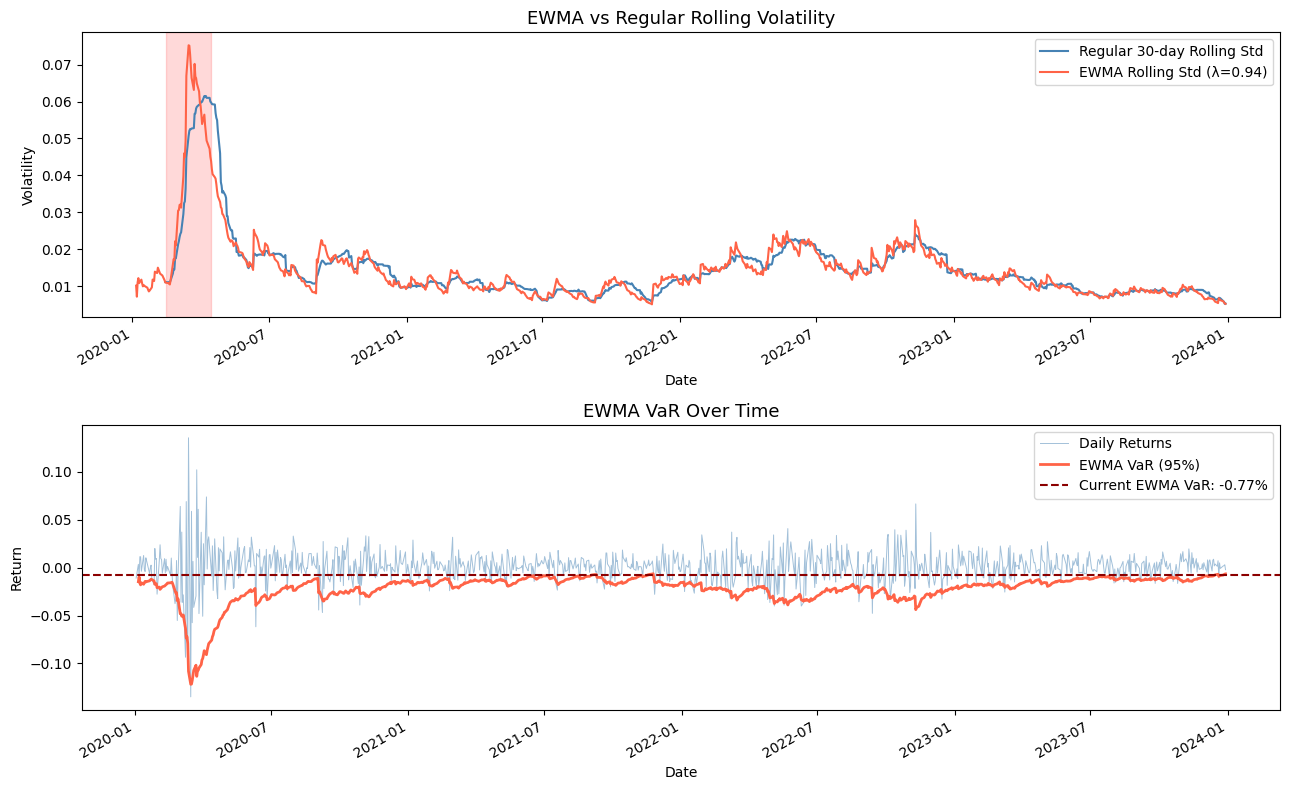

In [14]:
roll_std  = portfolio_r.rolling(window=30).std()
ewma_roll = portfolio_r.ewm(span=19, adjust=False).std()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

roll_std.plot(ax=axes[0],  color="steelblue", linewidth=1.5,
                  label="Regular 30-day Rolling Std")
ewma_roll.plot(ax=axes[0], color="tomato",    linewidth=1.5,
                   label="EWMA Rolling Std (λ=0.94)")
axes[0].set_title("EWMA vs Regular Rolling Volatility", fontsize=13)
axes[0].set_ylabel("Volatility")
axes[0].legend(fontsize=10)
axes[0].axvspan("2020-02-15", "2020-04-15",
                 alpha=0.15, color="red", label="COVID Crash")

ewma_var_s = ewma_mean + z * ewma_roll

portfolio_r.plot(ax=axes[1], color="steelblue", linewidth=0.7,
                  alpha=0.5, label="Daily Returns")
ewma_var_s.plot(ax=axes[1], color="tomato", linewidth=2,
                      label="EWMA VaR (95%)")
axes[1].axhline(ewma_var_val, color="darkred", linewidth=1.5,
                 linestyle="--", label=f"Current EWMA VaR: {ewma_var_val*100:.2f}%")
axes[1].set_title("EWMA VaR Over Time", fontsize=13)
axes[1].set_ylabel("Return")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("../data/adv3_ewma_var.png", dpi=150)
plt.show()

### Isolate the Crisis Period ###

In [16]:
crisis_start = "2020-02-20"
crisis_end   = "2020-03-23"    

crisis_r     = portfolio_r[crisis_start:crisis_end]
pre_crisis_r = portfolio_r["2020-01-01":"2020-02-19"]

print("=" * 50)
print("     STRESS TEST — COVID CRASH ANALYSIS")
print("=" * 50)
print(f"  Crisis Period    : {crisis_start} → {crisis_end}")
print(f"  Trading Days     : {len(crisis_r)}")
print("-" * 50)
print(f"  Cumulative Loss  : {crisis_r.sum()*100:.2f}%")
print(f"  Dollar Loss      : ${portfolio_v * abs(crisis_r.sum()):,.2f}")
print(f"  Worst Single Day : {crisis_r.min()*100:.2f}%")
print(f"  Avg Daily Loss   : {crisis_r.mean()*100:.2f}%")
print(f"  Crisis Volatility: {crisis_r.std()*100:.4f}%")
print(f"  Normal Volatility: {portfolio_r.std()*100:.4f}%")
print(f"  Vol Ratio        : {crisis_r.std()/portfolio_r.std():.1f}x higher during crisis")
print("-" * 50)

hist_var_95  = np.percentile(portfolio_r, 5)
breaches     = (crisis_r < hist_var_95).sum()
print(f"  VaR (95%) Limit  : {hist_var_95*100:.2f}%")
print(f"  Crisis Breaches  : {breaches} out of {len(crisis_r)} days")
print(f"  Breach Rate      : {breaches/len(crisis_r)*100:.1f}% (expected 5%)")
print("=" * 50)

     STRESS TEST — COVID CRASH ANALYSIS
  Crisis Period    : 2020-02-20 → 2020-03-23
  Trading Days     : 23
--------------------------------------------------
  Cumulative Loss  : -37.59%
  Dollar Loss      : $37,591.41
  Worst Single Day : -13.49%
  Avg Daily Loss   : -1.63%
  Crisis Volatility: 5.9804%
  Normal Volatility: 1.6909%
  Vol Ratio        : 3.5x higher during crisis
--------------------------------------------------
  VaR (95%) Limit  : -2.38%
  Crisis Breaches  : 13 out of 23 days
  Breach Rate      : 56.5% (expected 5%)


### Stress Test Visualization ###

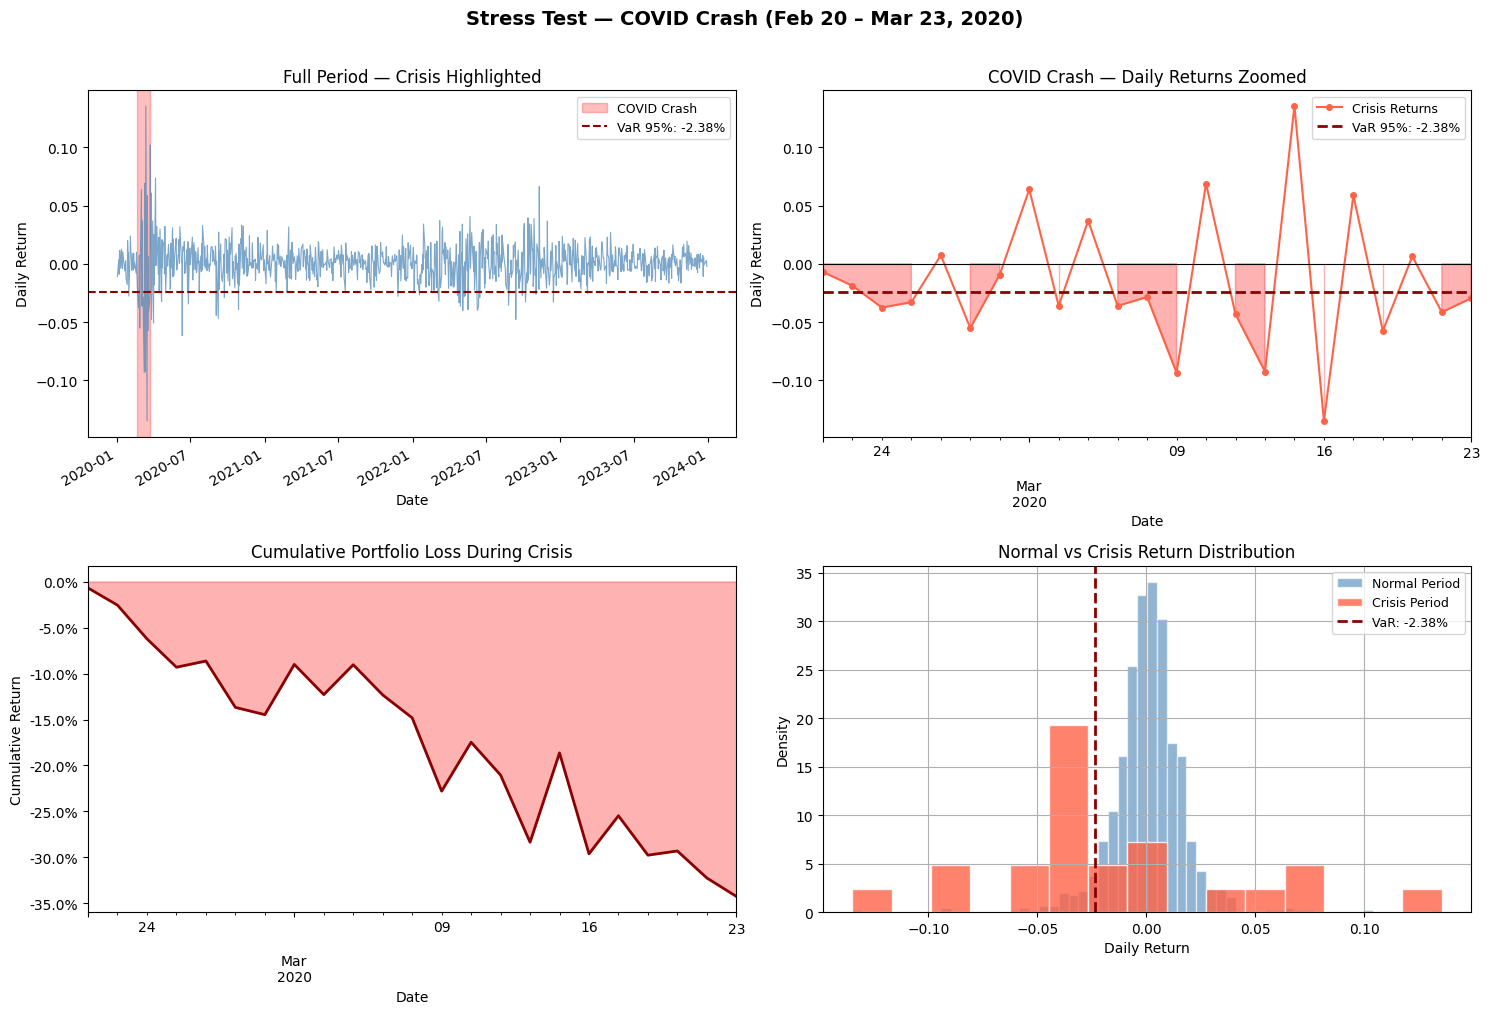

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

portfolio_r.plot(ax=axes[0,0], color="steelblue", linewidth=0.8, alpha=0.7)
axes[0,0].axvspan(crisis_start, crisis_end,
                   alpha=0.25, color="red", label="COVID Crash")
axes[0,0].axhline(hist_var_95, color="darkred", linewidth=1.5,
                   linestyle="--", label=f"VaR 95%: {hist_var_95*100:.2f}%")
axes[0,0].set_title("Full Period — Crisis Highlighted", fontsize=12)
axes[0,0].set_ylabel("Daily Return")
axes[0,0].legend(fontsize=9)

crisis_r.plot(ax=axes[0,1], color="tomato", linewidth=1.5, marker="o",
               markersize=4, label="Crisis Returns")
axes[0,1].axhline(hist_var_95, color="darkred", linewidth=2,
                   linestyle="--", label=f"VaR 95%: {hist_var_95*100:.2f}%")
axes[0,1].axhline(0, color="black", linewidth=0.8, linestyle="-")
axes[0,1].fill_between(crisis_r.index, crisis_r, 0,
                         where=(crisis_r < 0), color="red", alpha=0.3)
axes[0,1].set_title("COVID Crash — Daily Returns Zoomed", fontsize=12)
axes[0,1].set_ylabel("Daily Return")
axes[0,1].legend(fontsize=9)

cumulative = (1 + crisis_r).cumprod() - 1
cumulative.plot(ax=axes[1,0], color="darkred", linewidth=2)
axes[1,0].fill_between(cumulative.index, cumulative, 0,
                         color="red", alpha=0.3)
axes[1,0].set_title("Cumulative Portfolio Loss During Crisis", fontsize=12)
axes[1,0].set_ylabel("Cumulative Return")
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))

portfolio_r.hist(ax=axes[1,1], bins=60, density=True,
                  color="steelblue", alpha=0.6,
                  edgecolor="white", label="Normal Period")
crisis_r.hist(ax=axes[1,1], bins=15, density=True,
               color="tomato", alpha=0.8,
               edgecolor="white", label="Crisis Period")
axes[1,1].axvline(hist_var_95, color="darkred", linewidth=2,
                   linestyle="--", label=f"VaR: {hist_var_95*100:.2f}%")
axes[1,1].set_title("Normal vs Crisis Return Distribution", fontsize=12)
axes[1,1].set_xlabel("Daily Return")
axes[1,1].set_ylabel("Density")
axes[1,1].legend(fontsize=9)

plt.suptitle("Stress Test — COVID Crash (Feb 20 – Mar 23, 2020)",
              fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/adv4_stress_test.png", dpi=150, bbox_inches="tight")
plt.show()

### Master Summary (all methods, all extensions) ###

In [19]:
hist_var_95  = np.percentile(portfolio_r, 5)
hist_cvar_95 = portfolio_r[portfolio_r <= hist_var_95].mean()
param_var_95 = mu + norm.ppf(0.05) * sigma

print("=" * 65)
print("              MASTER SUMMARY — ALL METHODS")
print("=" * 65)
print(f"\n  Portfolio : AAPL(30%) MSFT(30%) JPM(20%) SPY(20%)")
print(f"  Period    : 2020-01-01 → 2023-12-31")
print(f"  Value     : ${portfolio_v:,}\n")
print(f"  {'Method':<25} {'VaR':>10} {'CVaR':>10} {'$ VaR':>12}")
print("-" * 65)
print(f"  {'Historical (95%)':<25} {hist_var_95*100:>9.2f}% "
      f"{hist_cvar_95*100:>9.2f}% ${portfolio_v*abs(hist_var_95):>10,.0f}")
print(f"  {'Parametric (95%)':<25} {param_var_95*100:>9.2f}% "
      f"{(mu - sigma*norm.pdf(norm.ppf(0.05))/0.05)*100:>9.2f}% "
      f"${portfolio_v*abs(param_var_95):>10,.0f}")
print(f"  {'EWMA (λ=0.94, 95%)':<25} {ewma_var_val*100:>9.2f}% "
      f"{ewma_cvar*100:>9.2f}% ${portfolio_v*abs(ewma_var_val):>10,.0f}")
print("-" * 65)
print(f"\n  Confidence Level Comparison (Historical VaR):")
for _, row in df_cl.iterrows():
    print(f"    {row['Confidence']}  →  {row['Hist VaR']*100:.2f}%  "
          f"(${row['Dollar Hist']:,.0f})")
print("-" * 65)
print(f"\n  Stress Test (COVID Crash Feb-Mar 2020):")
print(f"    Cumulative Loss  : {crisis_r.sum()*100:.2f}%")
print(f"    Dollar Loss      : ${portfolio_v*abs(crisis_r.sum()):,.2f}")
print(f"    VaR was exceeded : {breaches} out of {len(crisis_r)} days")
print(f"    Volatility spike : {crisis_r.std()/portfolio_r.std():.1f}x above normal")
print("=" * 65)

              MASTER SUMMARY — ALL METHODS

  Portfolio : AAPL(30%) MSFT(30%) JPM(20%) SPY(20%)
  Period    : 2020-01-01 → 2023-12-31
  Value     : $100,000

  Method                           VaR       CVaR        $ VaR
-----------------------------------------------------------------
  Historical (95%)              -2.38%     -3.88% $     2,378
  Parametric (95%)              -2.70%     -3.40% $     2,697
  EWMA (λ=0.94, 95%)            -0.77%     -1.02% $       770
-----------------------------------------------------------------

  Confidence Level Comparison (Historical VaR):
    90%  →  -1.64%  ($1,642)
    95%  →  -2.38%  ($2,378)
    99%  →  -4.42%  ($4,420)
-----------------------------------------------------------------

  Stress Test (COVID Crash Feb-Mar 2020):
    Cumulative Loss  : -37.59%
    Dollar Loss      : $37,591.41
    VaR was exceeded : 13 out of 23 days
    Volatility spike : 3.5x above normal
